# 02 Custom RK4 Implementation

This notebook implements the classical fourth-order Runge-Kutta method from scratch and applies it to the fixed Lorenz-1960 benchmark defined in `01_problem_setup.ipynb`.

## Why RK4 is included

The custom RK4 solver is not included because it is more advanced than modern adaptive solvers. It is included because it is transparent. Every update is visible, reproducible, and easy to audit, which makes it a strong baseline for later ANN work.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from lorenz1960_baseline import (
    DEFAULT_CONFIG,
    final_state_table,
    lorenz1960_rhs,
    plot_3d_trajectory,
    plot_state_time_series,
    rk4_solve,
)

plt.style.use("seaborn-v0_8-whitegrid")


## RK4 update rule

For step size `h`, RK4 computes four slope estimates:

\[
k_1 = f(t_n, y_n), \quad
k_2 = f\left(t_n + \frac{h}{2}, y_n + \frac{h}{2}k_1\right),
\]
\[
k_3 = f\left(t_n + \frac{h}{2}, y_n + \frac{h}{2}k_2\right), \quad
k_4 = f(t_n + h, y_n + hk_3).
\]

The state update is

\[
y_{n+1} = y_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4).
\]


In [2]:
config = DEFAULT_CONFIG
ts_rk4, ys_rk4 = rk4_solve(
    lorenz1960_rhs,
    config.t_span,
    config.initial_state,
    config.rk4_step,
)

final_state_table(ts=ts_rk4, ys=ys_rk4, solver_name="RK4")


,solver,state,final_value,time
0,RK4,x,0.412011,1.0
1,RK4,y,1.358844,1.0
2,RK4,z,0.630987,1.0


## Time-series plots

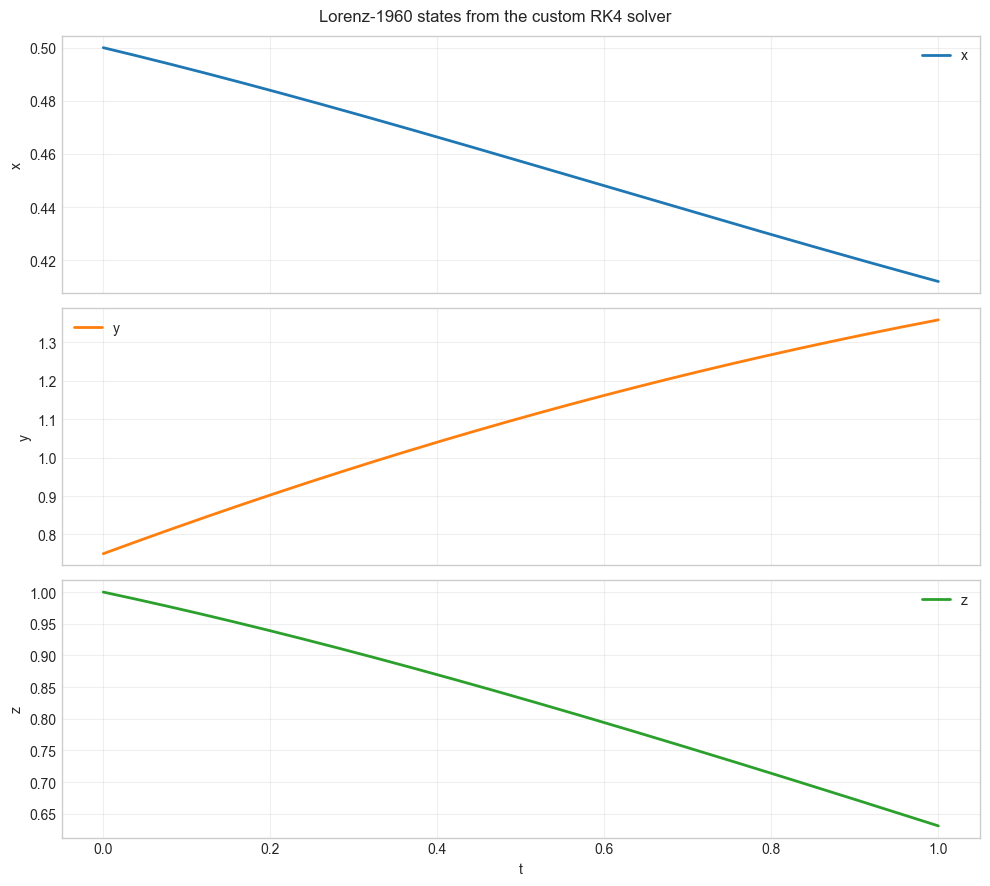

In [3]:
plot_state_time_series(
    ts_rk4,
    ys_rk4,
    title="Lorenz-1960 states from the custom RK4 solver",
)
plt.show()


## 3D trajectory plot

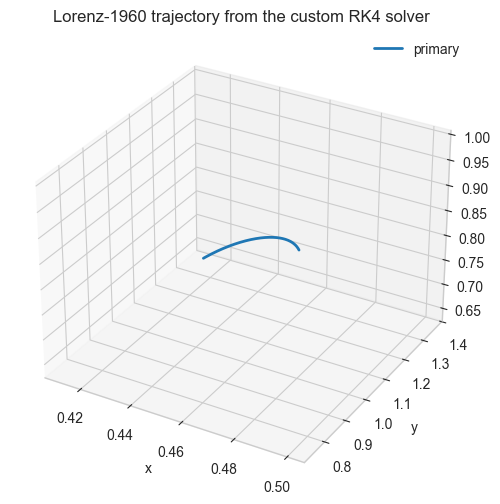

In [4]:
plot_3d_trajectory(
    ys_rk4,
    title="Lorenz-1960 trajectory from the custom RK4 solver",
)
plt.show()


## Interpretation

- This notebook only demonstrates the custom fixed-step RK4 simulation.
- Agreement with a scientific-library solver is not claimed here.
- That validation is performed explicitly in `04_validation_and_comparison.ipynb`.